In [41]:
import numpy as np
import matplotlib.pyplot as plt
import math
import torch
import random
random.seed(11)

In [42]:
# ── Synchronous EASGD ─────────────────────────────────────────────────────────
def easgd_2(grad,fn, theta,num_workers=4, eta=0.01, alpha=0.5,alpha_pull = 0.5,beta=0, num_epochs=300, dim=2):

    x_center = np.asarray(theta, dtype=float)
    workers = [
        x_center + 1.0 * np.random.randn(dim)
        for _ in range(num_workers)
    ]

    master_trajectory  = [x_center.copy()]
    worker_trajectories = [[w.copy()] for w in workers]  # one list per worker

    for e in range(num_epochs):
        if e % 50 ==0:
            losses = np.array([fn(workers[i]) for i in range(num_workers)])
            scaled = -beta * losses
            scaled -= scaled.max()  # subtract max for numerical stability
            exp_scaled = np.exp(scaled)
            w = exp_scaled / exp_scaled.sum()
            workers = np.array(workers)
            workers_temp = workers
            workers = workers - alpha_pull*w @ (workers - np.array(x_center))
            x_center = (1-alpha)*x_center + alpha * (w @ workers_temp)

            
        g = np.array([grad(workers[i]) for i in range(num_workers)])
        workers = (workers - eta   * g)
        for i in range(num_workers):
            worker_trajectories[i].append(workers[i].copy())  # record after each step

        master_trajectory.append(x_center.copy())

    return x_center, master_trajectory, worker_trajectories

# ── Plain Gradient Descent ────────────────────────────────────────────────────
def plain_gd(grad, x_init, eta=0.01, num_epochs=300):
    x = np.asarray(x_init, dtype=float)

    trajectory = [x.copy()]
    for _ in range(num_epochs):
        x = x - eta * grad(x)
        trajectory.append(x.copy())

    return x, trajectory

In [4]:
def easgd(grad, theta,num_workers=4, eta=0.01, rho=0.1, num_epochs=300, dim=2):
    alpha = eta * rho

    x_center = np.asarray(theta,dtype=float)
    workers = [
        x_center + 1 * np.random.randn(dim)
        for _ in range(num_workers)
    ]

    master_trajectory  = [x_center.copy()]
    worker_trajectories = [[w.copy()] for w in workers]  # one list per worker


    for e in range(num_epochs):
        for i in range(num_workers):
            if e % 50 ==0:
                workers[i] = (workers[i]
                            - alpha * (workers[i] - x_center))
                x_center    = x_center + alpha*(workers[i] - x_center)

            g = grad(workers[i])
            workers[i] = (workers[i]
                            - eta   * g)
            worker_trajectories[i].append(workers[i].copy())  # record after each step

        master_trajectory.append(x_center.copy())

    return x_center, master_trajectory, worker_trajectories

In [5]:
def noisy_grad(grad_fn, x, noise_scale=0.1):
    return grad_fn(x) + noise_scale * np.random.randn(len(x))

In [6]:
# ── Loss & gradient ───────────────────────────────────────────────────────────
def sphere_fn(theta):
    x, y = theta
    return x**2 + y**2

def sphere_gd(theta):
    x, y = theta
    return np.array([2*x, 2*y])   # FIX: must return a vector, not a scalar


# ── Rosenbrock  f(x,y) = (1-x)² + 100(y-x²)²  —  global min = 0 at (1, 1) ──
def rosenbrock_fn(theta):
    x, y = theta
    return (1 - x)**2 + 100 * (y - x**2)**2

def rosenbrock_gd(theta):
    x, y = theta
    dfdx = -2 * (1 - x) - 400 * x * (y - x**2)
    dfdy =  200 * (y - x**2)
    g = np.array([dfdx, dfdy])
    return np.clip(g, -10.0, 10.0)   # clip to prevent gradient explosion


def rastrigin_fn(theta):
    A = 10
    n = len(theta)
    return A * n + sum(x**2 - A * np.cos(2 * np.pi * x) for x in theta)

def rastrigin_gd(theta):
    A = 10
    return np.array([
        2*x + 2*np.pi*A * np.sin(2 * np.pi * x)
        for x in theta
    ])

def himmelblau_fn(theta):
    x, y = theta
    return (x**2 + y - 11)**2 + (x + y**2 - 7)**2

def himmelblau_gd(theta):
    x, y = theta
    dfdx = 4*x*(x**2 + y - 11) + 2*(x + y**2 - 7)
    dfdy = 2*(x**2 + y - 11) + 4*y*(x + y**2 - 7)
    return np.clip(np.array([dfdx, dfdy]), -10.0, 10.0)  # add this
def ackley_fn(theta):
    x, y = theta
    return (-20 * np.exp(-0.2 * np.sqrt(0.5*(x**2 + y**2)))
            - np.exp(0.5*(np.cos(2*np.pi*x) + np.cos(2*np.pi*y)))
            + np.e + 20)

def ackley_gd(theta):
    x, y = theta
    r = np.sqrt(0.5*(x**2 + y**2))
    exp1 = np.exp(-0.2 * r)
    exp2 = np.exp(0.5*(np.cos(2*np.pi*x) + np.cos(2*np.pi*y)))
    
    dfdx = (20 * exp1 * 0.2 * (0.5*x/r if r > 1e-10 else 0)
            + exp2 * np.pi * np.sin(2*np.pi*x))
    dfdy = (20 * exp1 * 0.2 * (0.5*y/r if r > 1e-10 else 0)
            + exp2 * np.pi * np.sin(2*np.pi*y))
    return np.clip(np.array([dfdx, dfdy]), -10.0, 10.0)



In [7]:
def benchmark(
    grad_fn,
    fn,
    n_inits=50,
    worker_seed_offset=1000,
    **easgd_kwargs
):

    sgd_losses = []
    easgd_losses = []

    for init_seed in range(n_inits):

        rng = np.random.default_rng(init_seed)

        # common starting point
        x0 = rng.uniform(-5, 5, size=2)

        # SGD
        sgd_final, _ = plain_gd(
            grad_fn,
            x_init=x0.copy(),
            eta=easgd_kwargs["eta"],
            num_epochs=easgd_kwargs["num_epochs"],
        )


        easgd_final, _, _ = easgd_2(
            grad_fn,
            fn,
            theta=x0.copy(),
            **easgd_kwargs,
        )

        sgd_losses.append(fn(sgd_final))
        easgd_losses.append(fn(easgd_final))

    return np.array(easgd_losses), np.array(sgd_losses)

In [ ]:
# try these parameters
easgd_kwargs_rastri = {
    "num_workers": 4,
    "eta": 0.0005012,
    "alpha": 0.325,
    "alpha_pull": 0.45,
    "beta": 5,
    "num_epochs": 2000,
    "dim": 2,
}
easgd_kwargs_ackely = {
    "num_workers": 4,
    "eta": 0.0005012,
    "alpha": 0.46,
    "alpha_pull": 0.45,
    "beta": 5,
    "num_epochs": 2000,
    "dim": 2,
}
sgd_kwargs = {"eta": 0.001, "num_epochs": 2000}

# sphere_losses_easgd, sphere_losses_sgd = benchmark(sphere_gd, sphere_fn, **easgd_kwargs)
# rosen_losses_easgd, rosen_losses_sgd = benchmark(rosenbrock_gd, rosenbrock_fn, **easgd_kwargs)
rastri_losses_easgd, rastri_losses_sgd = benchmark(rastrigin_gd, rastrigin_fn, **easgd_kwargs_rastri)
him_losses_easgd, him_losses_sgd = benchmark(himmelblau_gd, himmelblau_fn, **easgd_kwargs_rastri)
ack_losses_easgd, ack_losses_sgd = benchmark(ackley_gd, ackley_fn, **easgd_kwargs_ackely)

In [9]:
for name, e, s in [
    ("Rastrigin", rastri_losses_easgd, rastri_losses_sgd),
    ("Himmelblau", him_losses_easgd, him_losses_sgd),
    ("Ackley", ack_losses_easgd, ack_losses_sgd),
]:
    print(
        f"{name}: "
        f"win rate = {(e < s).mean():.2%}, "
        f"mean loss SGD = {s.mean():.4f}, "
        f"mean loss EASGD = {e.mean():.4f}"
    )

Rastrigin: win rate = 56.00%, mean loss SGD = 14.5263, mean loss EASGD = 14.7339
Himmelblau: win rate = 0.00%, mean loss SGD = 0.0000, mean loss EASGD = 53.0904
Ackley: win rate = 60.00%, mean loss SGD = 7.2419, mean loss EASGD = 6.4589


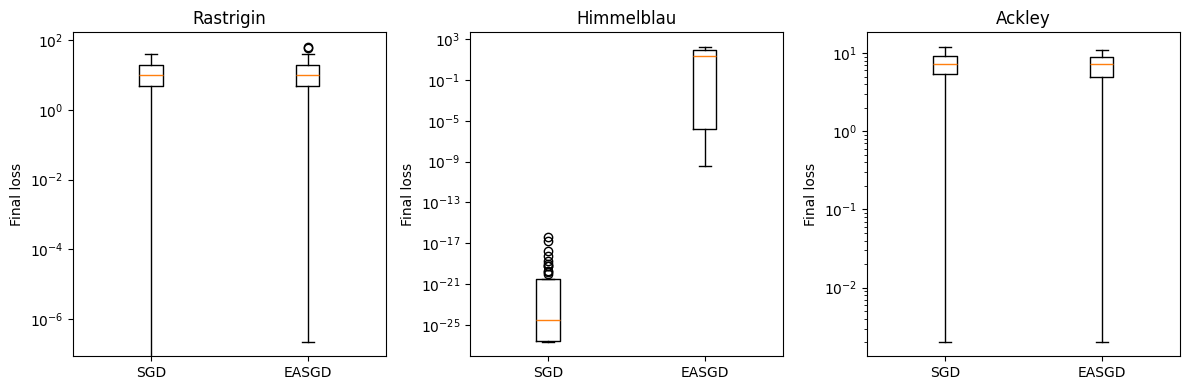

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
landscapes = [
    # ("Sphere", sphere_losses_easgd, sphere_losses_sgd),
    # ("Rosenbrock", rosen_losses_easgd, rosen_losses_sgd),
    ("Rastrigin", rastri_losses_easgd, rastri_losses_sgd),
    ("Himmelblau", him_losses_easgd, him_losses_sgd),
    ("Ackley", ack_losses_easgd, ack_losses_sgd),
]
for ax, (name, e_losses, s_losses) in zip(axes, landscapes):
    ax.boxplot([s_losses, e_losses], labels=["SGD", "EASGD"])
    ax.set_title(name)
    ax.set_ylabel("Final loss")
    ax.set_yscale("log")
plt.tight_layout()

In [20]:
def plot_master_vs_sgd(
    fn,
    sgd_traj,
    center_traj,
    xlim=(-5, 5),
    ylim=(-5, 5),
    title=""
):

    xs = np.linspace(*xlim, 400)
    ys = np.linspace(*ylim, 400)

    X, Y = np.meshgrid(xs, ys)

    Z = np.zeros_like(X)

    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i, j] = fn(np.array([X[i, j], Y[i, j]]))

    sgd_traj = np.asarray(sgd_traj)
    center_traj = np.asarray(center_traj)

    plt.figure(figsize=(8, 6))

    plt.contourf(
        X, Y,
        np.log1p(Z),
        levels=50
    )

    plt.colorbar(label="log(1 + loss)")

    step = 20

    plt.plot(
        sgd_traj[::step, 0],
        sgd_traj[::step, 1],
        'r-o',
        markersize=3,
        label="SGD"
    )
    plt.plot(
        sgd_traj[0, 0],
        sgd_traj[0, 1],
        'ro',
        ms=10
    )

    # EASGD master
    plt.plot(
        center_traj[:, 0],
        center_traj[:, 1],
        'w-',
        lw=2,
        label="EASGD master"
    )

    plt.plot(
        center_traj[-1, 0],
        center_traj[-1, 1],
        'w*',
        ms=14
    )

    plt.legend()
    plt.title(title)
    plt.xlabel("x")
    plt.ylabel("y")
    plt.show()

seed=2, SGD=7.96, EASGD=4.97


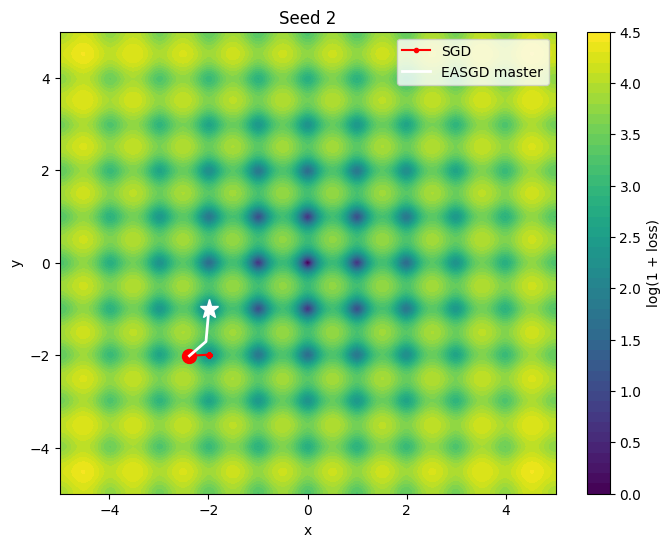

seed=3, SGD=24.87, EASGD=12.93


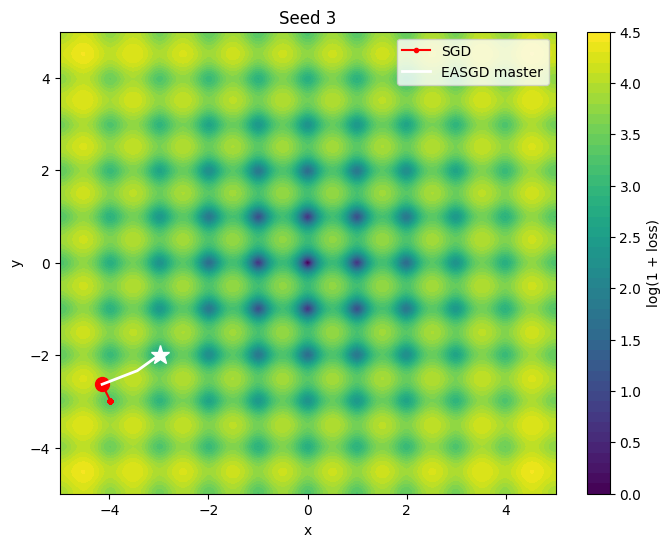

seed=5, SGD=17.91, EASGD=12.93


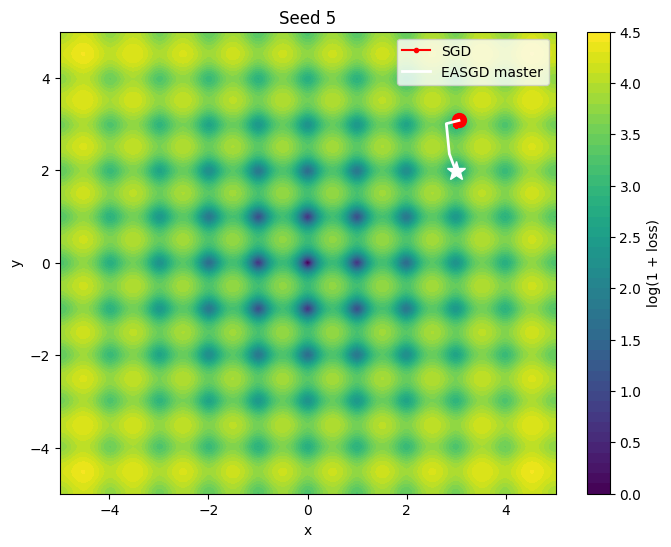

seed=6, SGD=3.98, EASGD=0.99


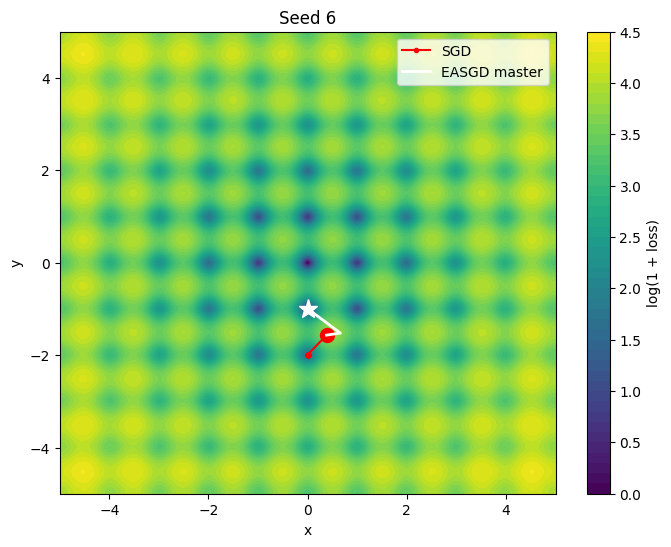

seed=7, SGD=16.91, EASGD=9.95


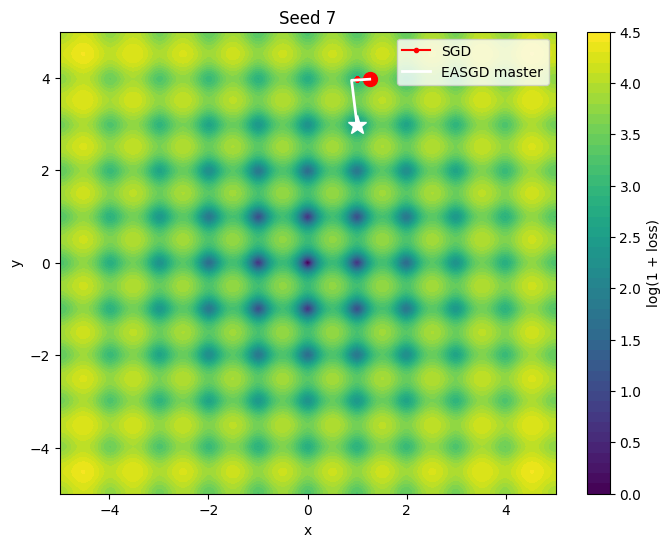

seed=8, SGD=28.85, EASGD=19.90


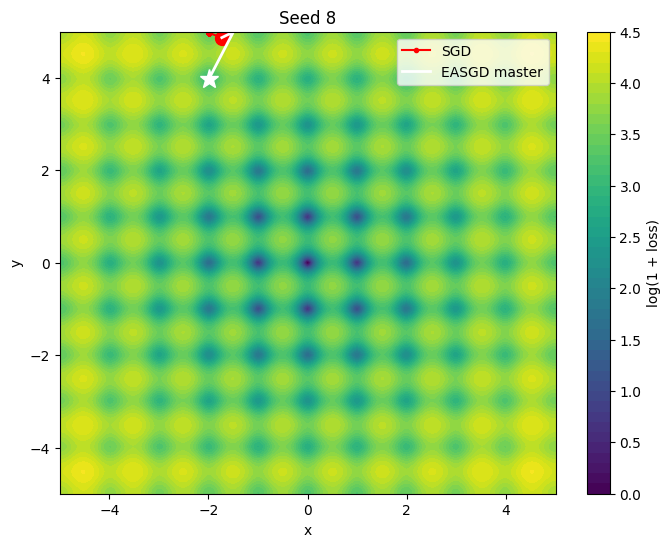

seed=9, SGD=19.90, EASGD=16.96


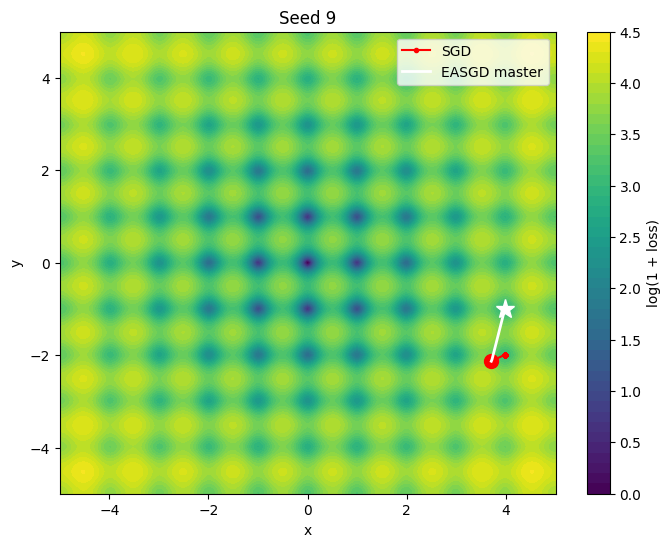

seed=10, SGD=33.83, EASGD=12.93


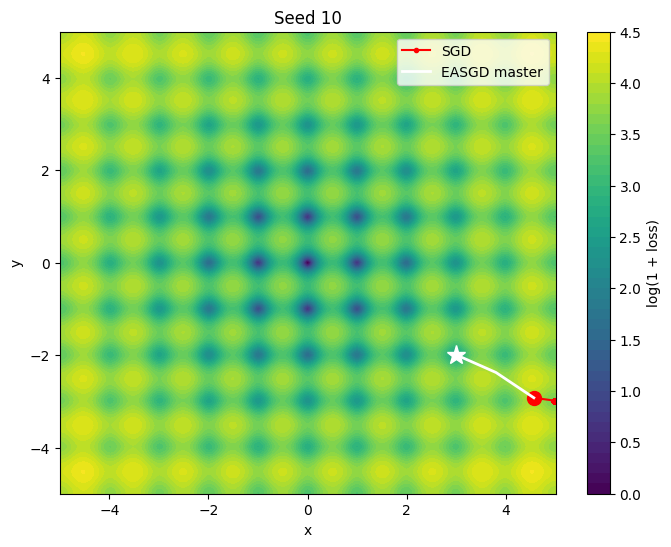

seed=11, SGD=15.92, EASGD=8.95


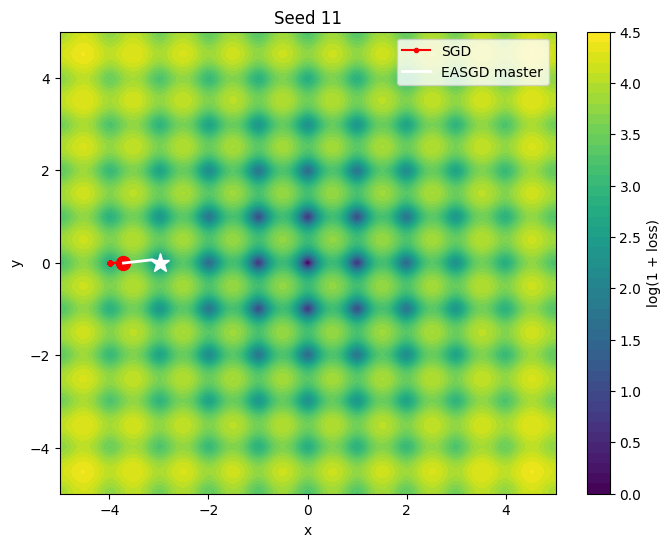

seed=12, SGD=19.90, EASGD=16.91


KeyboardInterrupt: 

In [21]:
for seed in range(50):

    rng = np.random.default_rng(seed)
    x0 = rng.uniform(-5, 5, size=2)

    sgd_final, sgd_traj = plain_gd(
        rastrigin_gd,
        x_init=x0.copy(),
        eta=0.001,
        num_epochs=2000
    )

    center_final, center_traj, _ = easgd_2(
        rastrigin_gd,
        rastrigin_fn,
        theta=x0.copy(),
        **easgd_kwargs_rastri
    )
    sgd_loss = rastrigin_fn(sgd_final)
    easgd_loss = rastrigin_fn(center_final)
    if easgd_loss < sgd_loss:
        print(
            f"seed={seed}, "
            f"SGD={sgd_loss:.2f}, "
            f"EASGD={easgd_loss:.2f}"
        )

        plot_master_vs_sgd(
            rastrigin_fn,
            sgd_traj,
            center_traj,
            title=f"Seed {seed}"
        )

In [26]:
def benchmark_three(
    grad_fn,
    fn,
    easgd2_kwargs,
    easgd_kwargs,
    sgd_kwargs,
    n_inits=50,
    

):

    sgd_losses = []
    easgd_losses = []
    easgd2_losses = []

    for seed in range(n_inits):

        rng = np.random.default_rng(seed)

        x0 = rng.uniform(-5, 5, size=2)

        # SGD
        sgd_final, _ = plain_gd(
            grad_fn,
            x_init=x0.copy(),
            eta=sgd_kwargs["eta"],
            num_epochs=sgd_kwargs["num_epochs"]
        )

        # Original EASGD
        easgd_final, _, _ = easgd(
            grad_fn,
            theta=x0.copy(),
            num_workers=easgd_kwargs["num_workers"],
            eta=easgd_kwargs["eta"],
            rho=easgd_kwargs["rho"],
            num_epochs=easgd_kwargs["num_epochs"],
            dim=easgd_kwargs["dim"]
        )

        # EASGD_2
        easgd2_final, _, _ = easgd_2(
            grad_fn,
            fn,
            theta=x0.copy(),
            eta = easgd2_kwargs["eta"],
            num_workers=easgd2_kwargs["num_workers"],
            alpha=easgd2_kwargs["alpha"],
            alpha_pull=easgd2_kwargs["alpha_pull"],
            beta = easgd2_kwargs["beta"],
            num_epochs=easgd2_kwargs["num_epochs"],
            dim=easgd2_kwargs["dim"]
        )

        sgd_losses.append(fn(sgd_final))
        easgd_losses.append(fn(easgd_final))
        easgd2_losses.append(fn(easgd2_final))

    return (
        np.array(sgd_losses),
        np.array(easgd_losses),
        np.array(easgd2_losses)
    )

In [27]:
easgd2_kwargs_rastri = {
    "num_workers": 4,
    "eta": 0.0005012,
    "alpha": 0.325,
    "alpha_pull": 0.45,
    "beta": 5,
    "num_epochs": 2000,
    "dim": 2,
}
easgd_kwargs_rastri = {
    "num_workers": 4,
    "eta": 0.01,
    "rho": 0.1,
    "num_epochs": 2000,
    "dim": 2,
}


sgd_kwargs_rasti= {"eta":0.001,"num_epochs":2000}

sgd_ras, easgd1_ras, easgd2_ras = benchmark_three(
    rastrigin_gd,
    rastrigin_fn,
    sgd_kwargs=sgd_kwargs_rasti,
    easgd_kwargs=easgd_kwargs_rastri,
    easgd2_kwargs=easgd2_kwargs_rastri,

)


In [29]:
print("EASGD vs SGD:",
      np.mean(easgd1_ras < sgd_ras))

print("EASGD_2 vs SGD:",
      np.mean(easgd2_ras < sgd_ras))

print("EASGD_2 vs EASGD:",
      np.mean(easgd2_ras < easgd1_ras))

EASGD vs SGD: 0.0
EASGD_2 vs SGD: 0.74
EASGD_2 vs EASGD: 0.98


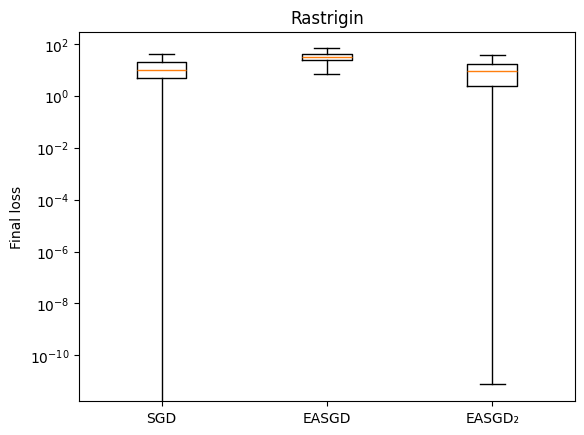

In [30]:
plt.boxplot(
    [sgd_ras, easgd1_ras, easgd2_ras],
    labels=["SGD", "EASGD", "EASGD₂"]
)
plt.yscale("log")
plt.ylabel("Final loss")
plt.title("Rastrigin")
plt.show()

In [15]:
improvement = easgd1 - easgd2

print("Average improvement of EASGD2 over EASGD:",
      improvement.mean())

Average improvement of EASGD2 over EASGD: 22.91916614533457


In [38]:
easgd2_kwargs_ackley = {
    "num_workers": 4,
    "eta": 0.0005012,
    "alpha": 0.325,
    "alpha_pull": 0.45,
    "beta": 5,
    "num_epochs": 2000,
    "dim": 2,
}
easgd_kwargs_ackley = {
    "num_workers": 4,
    "eta": 0.01,
    "rho": 0.1,
    "num_epochs": 2000,
    "dim": 2,
}

sgd, easgd1, easgd2 = benchmark_three(
    ackley_gd,
    ackley_fn,
    sgd_kwargs=sgd_kwargs_rasti,
    easgd_kwargs=easgd_kwargs_ackley,
    easgd2_kwargs=easgd2_kwargs_ackley,
)

In [43]:
print("EASGD vs SGD:",
      np.mean(easgd1 < sgd))

print("EASGD_2 vs SGD:",
      np.mean(easgd2 < sgd))

print("EASGD_2 vs EASGD:",
      np.mean(easgd2 < easgd1))

EASGD vs SGD: 0.0
EASGD_2 vs SGD: 0.58
EASGD_2 vs EASGD: 1.0


In [45]:
easgd2_kwargs_ackley = {
    "num_workers": 4,
    "eta": 0.0005012,
    "alpha": 0.325,
    "alpha_pull": 0.45,
    "beta": 5,
    "num_epochs": 2000,
    "dim": 2,
}
easgd_kwargs_ackley = {
    "num_workers": 4,
    "eta": 0.01,
    "rho": 0.1,
    "num_epochs": 2000,
    "dim": 2,
}

sgd, easgd1, easgd2 = benchmark_three(
    himmelblau_gd,
    himmelblau_fn,
    sgd_kwargs=sgd_kwargs_rasti,
    easgd_kwargs=easgd_kwargs_ackley,
    easgd2_kwargs=easgd2_kwargs_ackley,
)

In [46]:
print("EASGD vs SGD:",
      np.mean(easgd1 < sgd))

print("EASGD_2 vs SGD:",
      np.mean(easgd2 < sgd))

print("EASGD_2 vs EASGD:",
      np.mean(easgd2 < easgd1))

EASGD vs SGD: 0.0
EASGD_2 vs SGD: 0.0
EASGD_2 vs EASGD: 0.84


In [63]:
import numpy as np
import matplotlib.pyplot as plt

def plot_himmelblau_trajectories(
    sgd_traj,
    master_traj,
    worker_trajs,
    xlim=(-6, 6),
    ylim=(-6, 6)
):

    # Himmelblau landscape
    x = np.linspace(*xlim, 400)
    y = np.linspace(*ylim, 400)

    X, Y = np.meshgrid(x, y)

    Z = (X**2 + Y - 11)**2 + (X + Y**2 - 7)**2

    plt.figure(figsize=(10, 8))

    # Contours
    plt.contourf(
        X,
        Y,
        np.log1p(Z),
        levels=60,
        alpha=0.8
    )

    plt.colorbar(label="log(1 + f(x,y))")

    # SGD trajectory
    sgd = np.asarray(sgd_traj)

    plt.plot(
        sgd[:, 0],
        sgd[:, 1],
        color="red",
        linewidth=3,
        label="SGD"
    )

    plt.scatter(
        sgd[0, 0],
        sgd[0, 1],
        color="red",
        marker="o",
        s=80
    )

    plt.scatter(
        sgd[-1, 0],
        sgd[-1, 1],
        color="red",
        marker="*",
        s=200
    )

    # Master trajectory
    master = np.asarray(master_traj)

    step = 100
    plt.plot(
        master[::step, 0],
        master[::step, 1],
        color="white",
        linewidth=3,
        label="Master"
    )

    plt.scatter(
        master[-1, 0],
        master[-1, 1],
        color="white",
        marker="*",
        s=200
    )
    
    # Workers
    for i, worker in enumerate(worker_trajs):

        worker = np.asarray(worker)

        plt.plot(
            worker[::step, 0],
            worker[::step, 1],
            alpha=0.6,
            linewidth=1
        )
        plt.scatter(
            worker[-1, 0],
            worker[-1, 1],
            s=40
        )

    # Known Himmelblau minima
    minima = np.array([
        [3.0, 2.0],
        [-2.805118, 3.131312],
        [-3.779310, -3.283186],
        [3.584428, -1.848126]
    ])

    plt.scatter(
        minima[:, 0],
        minima[:, 1],
        marker="*",
        s=200,
        color="yellow",
        label="Global minima"
    )

    plt.xlabel("x")
    plt.ylabel("y")
    plt.title("Himmelblau Function: SGD vs EASGD")
    plt.legend()
    plt.tight_layout()
    plt.show()

In [69]:

easgd2_kwargs_him = {
    "num_workers": 4,
    "eta": 0.0005012,
    "alpha": 0.325,
    "alpha_pull": 0.45,
    "beta": 5,
    "num_epochs": 2000,
    "dim": 2,
}
easgd_kwargs_him = {
    "num_workers": 4,
    "eta": 0.01,
    "rho": 0.1,
    "num_epochs": 2000,
    "dim": 2,
}
x0 = [0,0]
# SGD
sgd_final, sgd_traj = plain_gd(
    himmelblau_gd,
    x_init=x0.copy(),
    eta=sgd_kwargs["eta"],
    num_epochs=sgd_kwargs["num_epochs"]
)

# EASGD_2
easgd2_final, master_traj, workers_traj = easgd_2(
    himmelblau_gd,
    himmelblau_fn,
    theta=x0.copy(),
    eta = easgd2_kwargs_him["eta"],
    num_workers=easgd2_kwargs_him["num_workers"],
    alpha=easgd2_kwargs_him["alpha"],
    alpha_pull=easgd2_kwargs_him["alpha_pull"],
    beta = easgd2_kwargs_him["beta"],
    num_epochs=easgd2_kwargs_him["num_epochs"],
    dim=easgd2_kwargs_him["dim"]
)

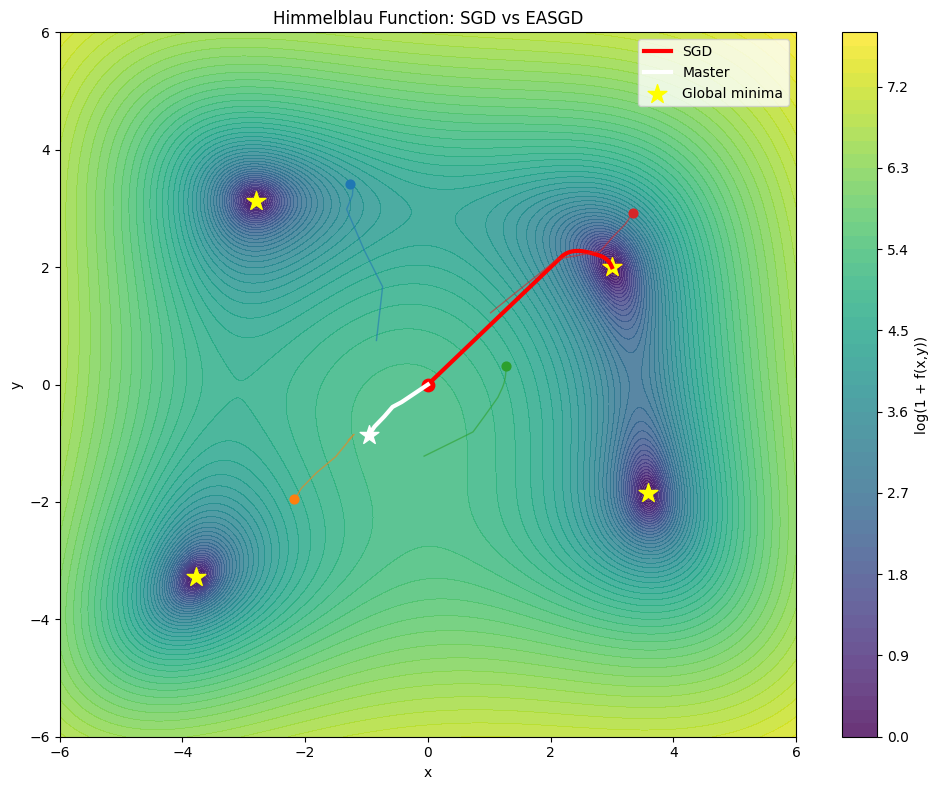

In [70]:
plot_himmelblau_trajectories(
    sgd_traj,
    master_traj,
    workers_traj
)